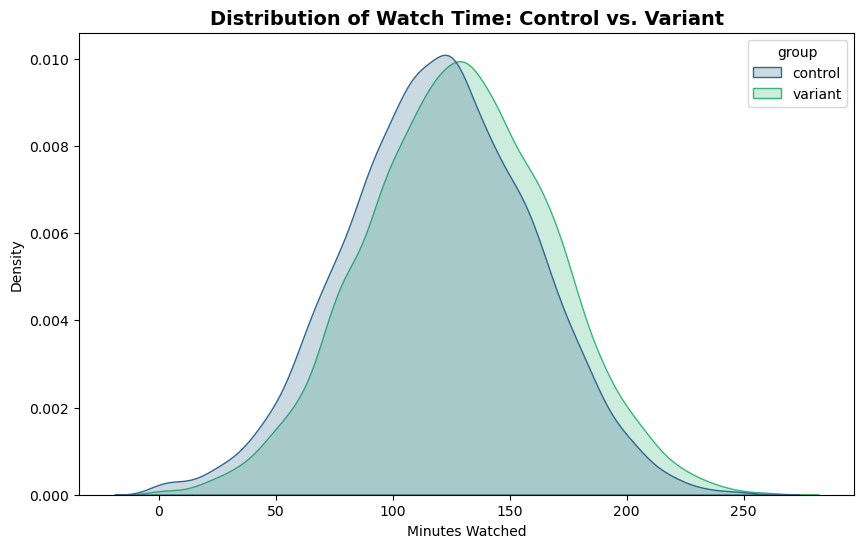

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setting Environment & Data Generation
np.random.seed(42)
if not os.path.exists('data'): os.makedirs('data')
if not os.path.exists('visuals'): os.makedirs('visuals')

n_users = 20000
data = pd.DataFrame({
    'user_id': range(1, n_users + 1),
    'group': np.random.choice(['control', 'variant'], size=n_users),
})

# Simulating watch time (Control: 120m, Variant: 128m)
data['watch_time'] = np.where(
    data['group'] == 'control',
    np.random.normal(120, 40, n_users),
    np.random.normal(128, 40, n_users)
).clip(min=0)

# 2. Data Export
data.to_csv('data/raw_engagement_data.csv', index=False)

# 3. Visualizing Distribution (KDE Plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='watch_time', hue='group', fill=True, palette='viridis', common_norm=False)
plt.title('Distribution of Watch Time: Control vs. Variant', fontsize=14, fontweight='bold')
plt.xlabel('Minutes Watched')
plt.ylabel('Density')

# Saving visual
plt.savefig('visuals/watch_time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()